In [1]:
suppressPackageStartupMessages({
	library(Biobase)
	library(BisqueRNA)
	library(Seurat)
	library(knitr)
	library(NanoStringNCTools)
	library(GeomxTools)
    library(Seurat)
    library(Matrix)
})

#bulk = read.csv("/home/dimitris/Workspace/crc/data/geomx_normalized_counts.csv", check.names=FALSE)
#metadata = read.csv('/home/dimitris/Workspace/crc/data/geomx_metadata.tsv', sep='\t')

set.seed(42)  
load('/home/dimitris/Workspace/crc/data/geomx_crc.RData')
target_demoData$location <- ifelse(target_demoData$location == 'front' ,'border',target_demoData$location)
target_demoData$mucinous <- ifelse(pData(target_demoData)$mucinous == 'true','mucinous','non-mucinous')
cd45_subset <- target_demoData[,pData(target_demoData)$segment == 'CD45']

bulk = assayDataElement(cd45_subset, elt = "q_norm" )

metadata = pData(cd45_subset)
# annotations_file = '/home/dimitris/Workspace/crc/data/geomx_annotations.csv'
# write.csv(metadata, file = annotations_file)

# bulk_file = "/home/dimitris/Workspace/crc/data/geomx_normalized_counts.csv"
# write.csv(bulk, file = bulk_file)

Warning message:
“package ‘Biobase’ was built under R version 4.4.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.4.2”
Warning message:
“package ‘BisqueRNA’ was built under R version 4.4.2”
Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Warning message:
“package ‘sp’ was built under R version 4.4.2”
Warning message:
“package ‘knitr’ was built under R version 4.4.3”
Warning message:
“package ‘NanoStringNCTools’ was built under R version 4.4.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.4.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘GeomxTools’ was built under R version 4.4.2”
Warning message:
“package ‘Matrix’ was built under R version 4.4.3”


In [2]:
bulk.matrix = as.matrix(bulk)
bulk.eset <- Biobase::ExpressionSet(assayData = bulk.matrix)

### Immune atlas from : https://www.science.org/doi/10.1126/science.abl5197

In [3]:
counts <- readMM("/mnt/backup/Workspace/crc/data/CrossTissueImmuneCellAtlas_matrix.mtx")
metadata <- read.csv("/mnt/backup/Workspace/crc/data/CrossTissueImmuneCellAtlas_metadata.csv", row.names = 1)
features <- read.csv("/mnt/backup/Workspace/crc/data/CrossTissueImmuneCellAtlas_features.csv")

colnames(counts) <- rownames(features)
rownames(counts) <- rownames(metadata)

seurat_obj <- CreateSeuratObject(counts = t(counts), 
                                meta.data = metadata,
                                assay = "RNA")


Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


Normalizing layer: counts

Finding variable features for layer counts

When using repel, set xnudge and ynudge to 0 for optimal results

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


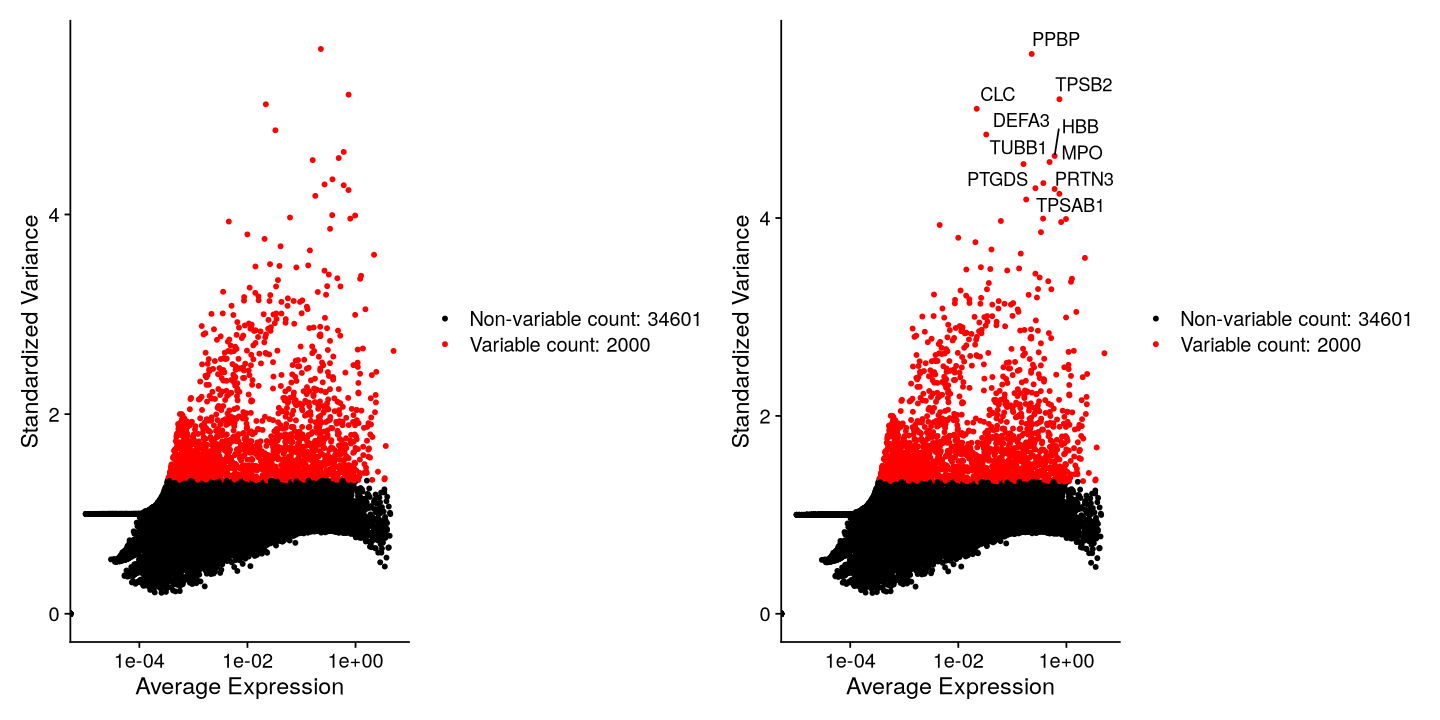

In [4]:
seurat_obj <- NormalizeData(seurat_obj)
seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 2000)

# Identify the 10 most highly variable genes
top10 <- head(VariableFeatures(seurat_obj), 10)
options(repr.plot.width=12, repr.plot.height=6)

# plot variable features with and without labels
plot1 <- VariableFeaturePlot(seurat_obj)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot1 + plot2

In [5]:
all.genes <- rownames(seurat_obj)
seurat_obj <- ScaleData(seurat_obj, features = all.genes)
seurat_obj <- RunPCA(seurat_obj, features = VariableFeatures(object = seurat_obj))

Centering and scaling data matrix

PC_ 1 
Positive:  TUBB1, GP9, TMEM40, CMTM5, ITGB3, TREML1, GNG11, MPIG6B, CLEC1B, LY6G6F 
	   ESAM, MYL9, FAXDC2, SPARC, SEPTIN5, C2orf88, PF4V1, TUBA8, F13A1, MYLK 
	   AP003068.2, GP1BA, LINC00989, ALOX12, GP6, GAS2L1, NRGN, TRIM58, HBG2, SNCA 
Negative:  FOS, JUND, KLF6, BTG1, DUSP1, JUN, JUNB, ZFP36, HSP90AA1, FOSB 
	   VIM, KLF2, CXCR4, TXNIP, IER2, CD74, CD52, BTG2, CRIP1, HSP90B1 
	   HSPA5, NEAT1, CD69, NR4A2, HLA-DRB1, HLA-DRA, RGS2, HSPA8, GADD45B, ALOX5AP 
PC_ 2 
Positive:  SERPINA1, C5AR1, SLC11A1, NCF2, FPR1, MARCO, LRP1, PLBD1, TREM1, VSIG4 
	   CD14, MS4A7, MRC1, OLR1, MCEMP1, IGSF6, MAFB, CYP27A1, FN1, C1QC 
	   GPNMB, MSR1, C1QA, KCTD12, ACSL1, LPL, MMP19, C1QB, CD68, CSTA 
Negative:  CD69, FCMR, TRBC2, IFITM1, PTPRCAP, CD79A, MS4A1, ISG20, LY9, CD3E 
	   BANK1, CD79B, HSPA8, CD27, PRDX2, SPOCK2, CCR7, IL32, DNAJB1, CD3G 
	   RALGPS2, CD19, CLEC2D, CD3D, TNFRSF13C, VPREB3, ABLIM1, BLK, CD2, TSPYL2 
PC_ 3 
Positive:  IRF8, HLA-DRA, HL

In [6]:
seurat_obj <- RunUMAP(seurat_obj, dims = 1:10)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
15:29:08 UMAP embedding parameters a = 0.9922 b = 1.112

15:29:08 Read 6856 rows and found 10 numeric columns

15:29:08 Using Annoy for neighbor search, n_neighbors = 30

15:29:08 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:29:09 Writing NN index file to temp file /tmp/RtmpwcuAjM/file1abc27bca6d5

15:29:09 Searching Annoy index using 1 thread, search_k = 3000

15:29:11 Annoy recall = 100%

15:29:11 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors =

[1] "orig.ident"                      "nCount_RNA"                     
 [3] "nFeature_RNA"                    "Organ"                          
 [5] "Donor"                           "Chemistry"                      
 [7] "Cell_category"                   "Predicted_labels_CellTypist"    
 [9] "Majority_voting_CellTypist"      "Majority_voting_CellTypist_high"
[11] "Manually_curated_celltype"

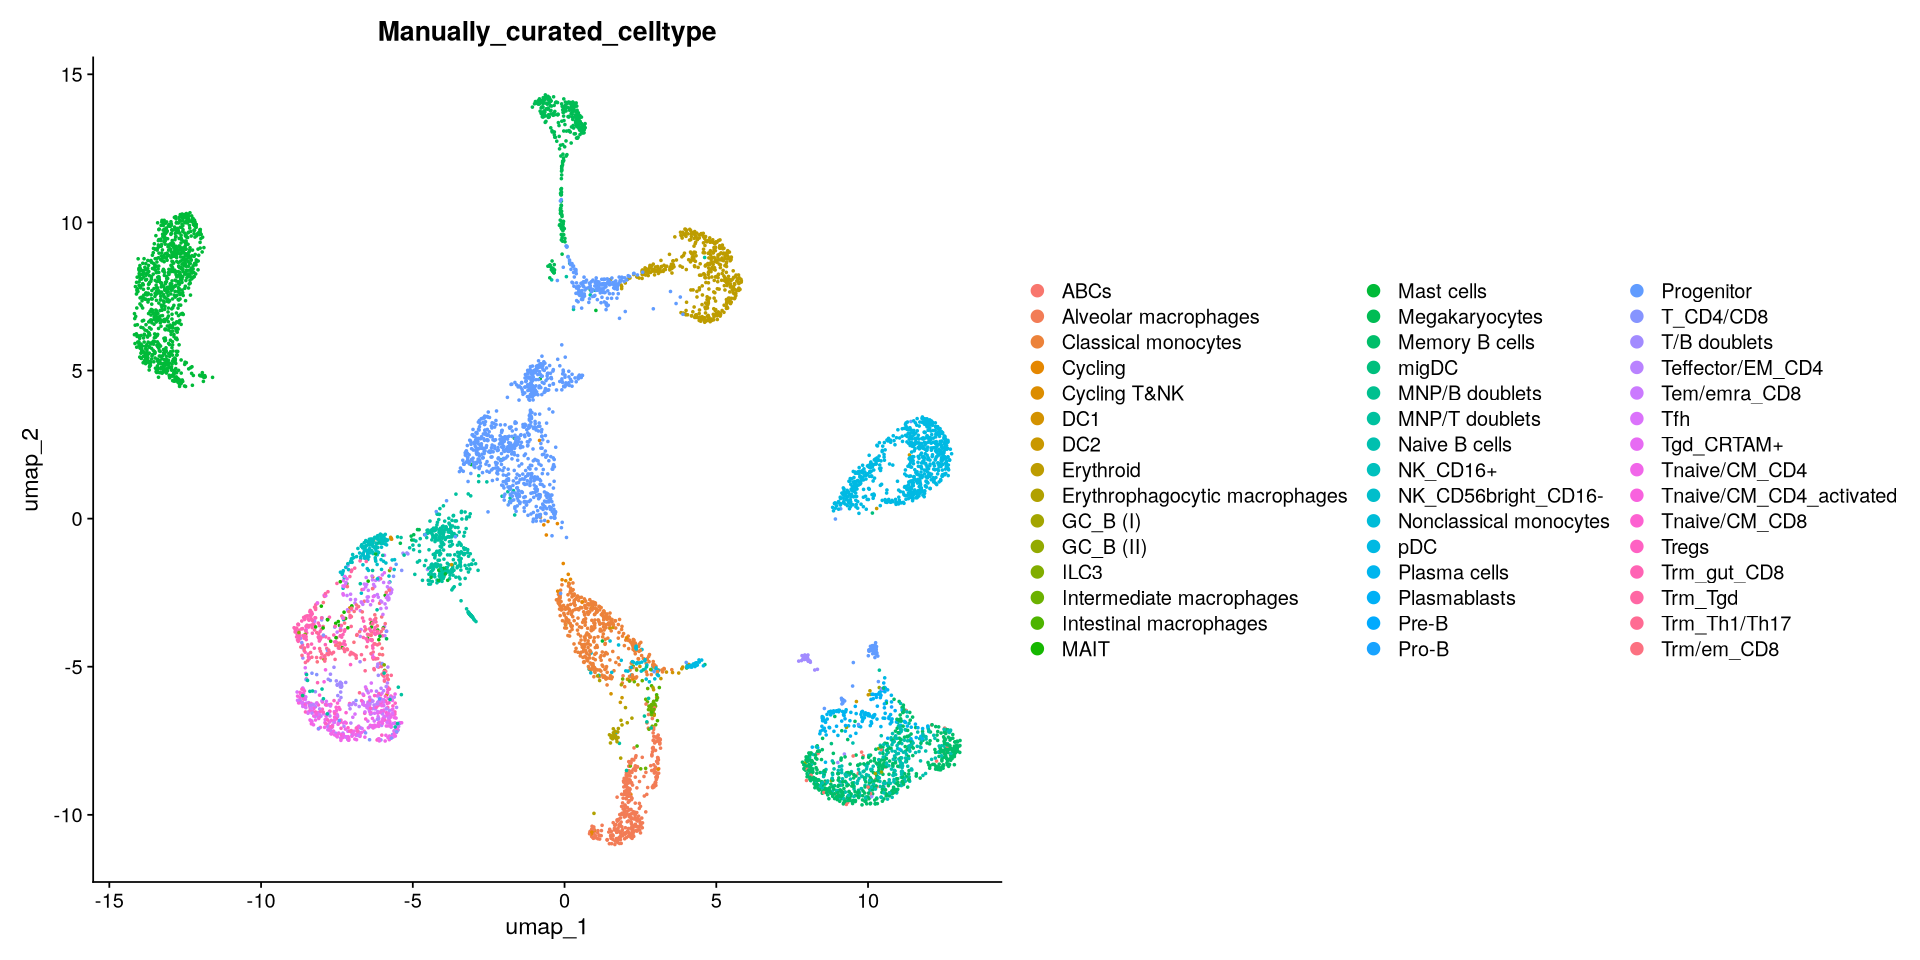

In [7]:
options(repr.plot.width=16, repr.plot.height=8)
colnames(seurat_obj@meta.data)
DimPlot(seurat_obj, group = "Manually_curated_celltype")

In [8]:
head(counts)

  [[ suppressing 34 column names ‘MIR1302-2HG’, ‘FAM138A’, ‘OR4F5’ ... ]]



6 x 36601 sparse Matrix of class "dgTMatrix"
                                                                               
Pan_T7980364_TAGTGGTTCCGTAGTA . . . . . . . . . . . . . . .         . .        
CZINY-0105_TCGAACAAGTCTCGTA   . . . . . . . . . . . . . . .         . .        
Pan_T7980364_CCTACACCACCCATGG . . . . . . . . . . . . . . .         . .        
CZINY-0050_TGTACAGAGACGATAT   . . . . . . . . . . . . . . .         . .        
CZINY-0053_CATGGTAGTTGGACCC   . . . . . . . . . . . . . . .         . .        
CZINY-0100_ACTGCAAAGGGAGGTG   . . . . . . . . . . . . . . 0.3613694 . 0.3613694
                                                                              
Pan_T7980364_TAGTGGTTCCGTAGTA . . . . . . . .         . . . . . .        . . .
CZINY-0105_TCGAACAAGTCTCGTA   . . . . . . . 0.2428669 . . . . . 1.578687 . . .
Pan_T7980364_CCTACACCACCCATGG . . . . . . . .         . . . . . 1.786880 . . .
CZINY-0050_TGTACAGAGACGATAT   . . . . . . . .         . . . . . .        . . .


In [9]:
sample.ids <- rownames(counts)
individual.labels <-seurat_obj@meta.data$orig.ident
cell.type.labels <- seurat_obj@meta.data$Manually_curated_celltype
# individual.ids and cell.types should be in the same order as in sample.ids
sc.pheno <- data.frame(check.names=F, check.rows=F,
                       stringsAsFactors=F,
                       row.names=sample.ids,
                       SubjectName=individual.labels,
                       cellType=cell.type.labels)

sc.meta <- data.frame(labelDescription=c("SubjectName",
                                         "cellType"),
                      row.names=c("SubjectName",
                                  "cellType"))
sc.pdata <- new("AnnotatedDataFrame",
                data=sc.pheno,
                varMetadata=sc.meta)

scaled_data <- GetAssayData(seurat_obj, assay = "RNA", layer = "scale.data")

In [10]:
sc.eset <- Biobase::ExpressionSet(assayData=t(as.matrix(counts)), phenoData=sc.pdata)

res <- BisqueRNA::ReferenceBasedDecomposition(bulk.eset, sc.eset, markers=NULL, use.overlap=F)

ref.based.estimates <- res$bulk.props
knitr::kable(ref.based.estimates[1:4,1:4], digits=2)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.9 GiB”
Decomposing into 45 cell types.

Using 17236 genes in both bulk and single-cell expression.

Converting single-cell counts to CPM and filtering zero variance genes.

Filtered 1617 zero variance genes.

Converting bulk counts to CPM and filtering unexpressed genes.

Filtered 0 unexpressed genes.

Generating single-cell based reference from 6856 cells.


Inferring bulk transformation from single-cell alone.

Applying transformation to bulk samples and decomposing.





|                     | DSP-1001660005664-D-B05.dcc| DSP-1001660005664-D-B07.dcc| DSP-1001660005664-D-B09.dcc| DSP-1001660005664-D-B11.dcc|
|:--------------------|---------------------------:|---------------------------:|---------------------------:|---------------------------:|
|ABCs                 |                        0.02|                        0.01|                        0.01|                        0.01|
|Alveolar macrophages |                        0.05|                        0.05|                        0.05|                        0.05|
|Classical monocytes  |                        0.07|                        0.08|                        0.06|                        0.06|
|Cycling              |                        0.00|                        0.00|                        0.00|                        0.00|

In [11]:
write.csv(ref.based.estimates,file = '/home/dimitris/Workspace/crc/data/cd45_momac_deconvoluted.csv')
